In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score,precision_score,recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline

In [43]:
df=pd.read_csv("heart.csv")

In [44]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [45]:
df.shape

(303, 14)

In [46]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [47]:
df.duplicated().sum()

np.int64(1)

In [48]:
df=df.drop_duplicates()

In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
157,35,1,1,122,192,0,1,174,0,0.0,2,0,2,1
80,41,1,2,112,250,0,1,179,0,0.0,2,0,2,1
277,57,1,1,124,261,0,1,141,0,0.3,2,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
223,56,0,0,200,288,1,0,133,1,4.0,0,2,3,0


In [51]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [52]:
df["target"].value_counts()

target
1    164
0    138
Name: count, dtype: int64

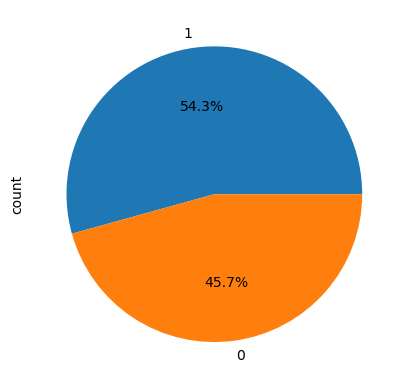

In [53]:
df["target"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.show()

In [54]:
df['sex'].value_counts()

sex
1    206
0     96
Name: count, dtype: int64

<Axes: xlabel='sex'>

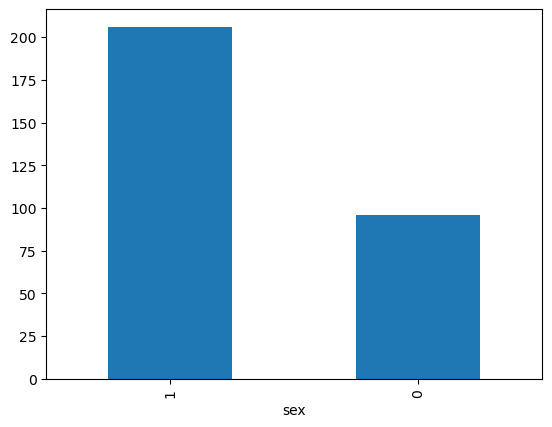

In [55]:
df['sex'].value_counts().plot(kind="bar")

<Axes: ylabel='age'>

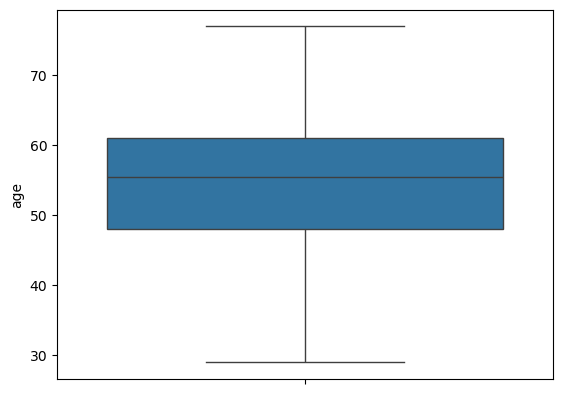

In [56]:
sns.boxplot(df['age'])

In [57]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trestbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalach,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exang,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


In [58]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [59]:
x=df.drop("target",axis=1)

In [60]:
x.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [61]:
y=df['target']

In [62]:
y.sample(6)

290    0
198    0
226    0
253    0
138    1
258    0
Name: target, dtype: int64

In [63]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [64]:
tr1=ColumnTransformer(
    [("Scaled",StandardScaler(),slice(0,None))
    ],remainder="passthrough"
)

In [65]:
lr=LogisticRegression()
nb=GaussianNB()
sm=SVC()

In [66]:
pipe=make_pipeline(tr1,nb)

In [67]:
pipe.fit(X_train,Y_train)

,steps,"[('columntransformer', ...), ('gaussiannb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Scaled', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [68]:
y_pred=pipe.predict(X_test)

In [69]:
print("Accuracy Score of Model:",accuracy_score(Y_test,y_pred))
print("precision Score of Model:",precision_score(Y_test,y_pred))
print("recol Score of Model:",recall_score(Y_test,y_pred))

Accuracy Score of Model: 0.8852459016393442
precision Score of Model: 0.9310344827586207
recol Score of Model: 0.84375


In [70]:
import joblib

In [71]:
joblib.dump(pipe,"Heart_disease.joblib")

['Heart_disease.joblib']

In [72]:
x.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')